In [1]:
# Anchor working directory to project root so all relative paths resolve correctly.
# Jupyter kernels default to the notebook's own directory (notebooks/), not the project root.
# This cell must be run first and run only once per session.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: c:\Users\Joshua\outage-scheduler


## Asset Scheduler — Demo Notebook

This notebook mirrors `main.py` exactly, executing each pipeline stage in sequence.
Each section names the function called, the file it lives in, and its inputs and outputs.
Run cells top-to-bottom to reproduce the same output files as `main.py`.

### Call flow
```
① load_config          data_loader.py
② preprocess_data      data_loader.py
③ create_df_impute     data_loader.py
④ distribute_months    model.py          ← CP-SAT solve #1 (month assignment)
⑤ split_solution_to_seasonal_batches    solution_parser.py
⑥ convert_batches_to_mvs               data_loader.py
⑦ solve_assets_for_each_season         solution_parser.py  ← CP-SAT solves #2–5
   └─ [visualise]  read_and_plot_batch_season_solutions    (notebook only)
⑧ create_full_season_solutions         solution_parser.py
⑨ merge_season_solutions               solution_parser.py
⑩ postprocess_data                     solution_parser.py
```

In [2]:
%matplotlib inline
import calendar
import pickle
import time
import pandas as pd
from IPython.display import display

from scheduler import (
    load_config,
    preprocess_data,
    create_df_impute,
    distribute_months,
    split_solution_to_seasonal_batches,
    convert_batches_to_mvs,
    solve_assets_for_each_season,
    create_full_season_solutions,
    merge_season_solutions,
    postprocess_data,
)
from scheduler.solution_parser import read_and_plot_batch_season_solutions

seasons = ["Summer", "Autumn", "Winter", "Spring"]

---
### ① `load_config()` — `scheduler/data_loader.py`

**Input:** `config.json`  
**Output:** `config` dict — file paths, AOP year, and public holidays parsed into `date` objects

In [3]:
config = load_config()

print(f"Asset requests filepath: {config['asset_requests_filepath']}")
print(f"Historical file:  {config['historical_durations_filepath']}")
print(f"Relational file:  {config['relational_dependencies_filepath']}")
print(f"AOP year:         {config['aop_year']}")
print(f"Public holidays:  {len(config['public_holidays'])} dates")
print("\nFirst 3 holidays:")
for h in config["public_holidays"][:3]:
    print(f"  {h}")

Asset requests filepath: data/asset_requests.xlsx
Historical file:  data/historical_durations.xlsx
Relational file:  data/relational_dependencies.xlsx
AOP year:         2026
Public holidays:  16 dates

First 3 holidays:
  2026-07-10
  2026-10-26
  2026-12-25


---
### ② `preprocess_data()` — `scheduler/data_loader.py`

**Input:** `config['asset_requests_filepath']` (Excel)  
**Output:** cleaned DataFrame written **back to the same file** (in-place overwrite)

Removes duplicate asset rows by grouping on `Asset` and concatenating unique values
across all other columns (bundled assets, conflicting assets, etc.).

On first call a raw backup (`_backup.xlsx`) is created alongside the source file.
All subsequent calls preprocess from that backup, so this cell is safe to re-run.

In [4]:
df_before = pd.read_excel(config["asset_requests_filepath"])
print(f"Rows before preprocessing: {len(df_before)}")
print(f"Unique assets:             {df_before['Asset'].nunique()}")

df_cleaned = preprocess_data(config)

print(f"\nRows after preprocessing:  {len(df_cleaned)}")
print(f"Duplicates removed:        {len(df_before) - len(df_cleaned)}")
print("\nSample output:")
display(df_cleaned.head())

Rows before preprocessing: 987
Unique assets:             987

Rows after preprocessing:  987
Duplicates removed:        0

Sample output:


,Asset,Planned Start Date,Planned Start Time,Planned Finished Date,Planned Finish Time,Nature,Time Frame,Region,Description of Work,Work Plan Details,Request Reason,Requestor,Window Owner,Job Manager
0,ASSET_0023,2026-08-17,,,,,,ZONE_0005,"JOB_0012,JOB_0010,JOB_0005","WP_1455,WP_1442,WP_1542,WP_1761,WP_1620",PM,,COORDINATOR_0118,
1,ASSET_0024,2026-08-17,,,,,,ZONE_0005,"JOB_0011,JOB_0006,JOB_0013","WP_1763,WP_1676,WP_1665,WP_1467,WP_1490",PM,,COORDINATOR_0118,
2,ASSET_0031,2026-07-10,,,,,,ZONE_0005,"JOB_0014,JOB_0009,JOB_0007",WP_5339,APJ,,"COORDINATOR_0001,COORDINATOR_0118",Manager_AV
3,ASSET_0032,"2026-07-01,2026-07-10,2026-07-10",,,,,,"ZONE_0004,ZONE_0004,ZONE_0005","JOB_3925,JOB_3923,JOB_3924,JOB_3922,JOB_3920,J...","WP_3484,WP_4716,WP_4717,WP_4715,WP_4713,WP_471...","CAP,CAP,APJ,CAP,APJ",,"COORDINATOR_0118,COORDINATOR_0118,COORDINATOR_...",Manager_AV
4,ASSET_0034,2026-07-10,,,,,,ZONE_0004,JOB_3917,WP_4699,CAP,,COORDINATOR_0118,


---
### ③ `create_df_impute()` — `scheduler/data_loader.py`

**Inputs:** `historical_durations_filepath`, `relational_dependencies_filepath`, `asset_requests_filepath`  
**Output:** `df_all_impute` — assets joined with historical durations (`HistMedDuration`) and relational metadata

Joins three sources on `Asset` to produce a single enriched DataFrame
used by the month-distribution solver.

In [5]:
df_all_impute = create_df_impute(
    config["historical_durations_filepath"],
    config["relational_dependencies_filepath"],
    config["asset_requests_filepath"],
)

print(f"Shape: {df_all_impute.shape}")
print(f"Columns: {list(df_all_impute.columns)}")
print()
display(df_all_impute.head())

Shape: (987, 5)
Columns: ['Asset', 'Historical and Preferred Months', 'HistMedDuration', 'Bundled Assets', 'Conflicting Assets']



,Asset,Historical and Preferred Months,HistMedDuration,Bundled Assets,Conflicting Assets
0,ASSET_0023,"Oct, Aug, Mar, Jul, Apr, May, Jun, Sep",1.0,NaN,NaN
1,ASSET_0024,"Oct, Aug, Mar, Jul, Apr, May, Jun, Sep, Nov",1.0,NaN,NaN
2,ASSET_0031,"Oct, Aug, Mar, Jul, Apr, May, Jun, Sep",1.0,ASSET_0016,NaN
3,ASSET_0032,"Oct, Nov, Dec",2.0,NaN,"ASSET_0020, ASSET_10269"
4,ASSET_0034,"Oct, Nov, Dec",1.0,ASSET_10269,ASSET_0021


---
### ④ `distribute_months()` — `scheduler/model.py` — CP-SAT solve #1

**Input:** `df_all_impute`  
**Output:** `solution` — dict keyed by `(asset, month_abbr)` → 0 or 1

Each asset is assigned to exactly one month. Constraints enforce:
- dependency groups land in the same month
- per-month concurrency limits are respected

The objective minimises workload imbalance across months and penalises assignments outside
each asset's historically preferred months.

In [6]:
t0 = time.time()
solution = distribute_months(df_all_impute)
elapsed = time.time() - t0
print(f"Solve time: {elapsed:.1f}s")

# Month-by-month assignment counts
months = [calendar.month_abbr[i] for i in range(1, 13)]
assets = list(df_all_impute["Asset"])
month_counts = {
    m: sum(1 for a in assets if solution.get((a, m), 0) == 1)
    for m in months
}
month_series = pd.Series(month_counts, name="Assets Assigned")
month_series.index.name = "Month"
print("\nAssets assigned per month:")
display(month_series.to_frame().T)

00:43:43 Solving
optimal

Advanced usage:
Problem solved in 2.483299 seconds
Solve time: 2.7s

Assets assigned per month:


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Assets Assigned,81,81,83,83,82,83,83,82,81,83,82,83


---
### ⑤ `split_solution_to_seasonal_batches()` — `scheduler/solution_parser.py`

**Inputs:** `df_all_impute`, `solution`, `seasons`, `config`  
**Output:** `df_soln` — DataFrame with `Assigned Month` and `Season` columns  
**Side-effect:** writes `outputs/05_season_batches_{season}.xlsx` for each season

Month → season mapping:  
Jan, Feb, Dec → **Summer** | Mar–May → **Autumn** | Jun–Aug → **Winter** | Sep–Nov → **Spring**

In [7]:
df_soln = split_solution_to_seasonal_batches(df_all_impute, solution, seasons, config)

print("Season distribution:")
display(df_soln["Season"].value_counts().rename("Assets").to_frame())

print("\nSample rows:")
display(df_soln[["Asset", "Assigned Month", "Season"]].head(10))

print("\nFiles written:")
for s in seasons:
    print(f"  outputs/05_season_batches_{s}.xlsx")

Season distribution:


,Assets
Season,
Winter,248
Autumn,248
Spring,246
Summer,245



Sample rows:


,Asset,Assigned Month,Season
0,ASSET_0023,7,Winter
1,ASSET_0024,7,Winter
2,ASSET_0031,7,Winter
3,ASSET_0032,12,Summer
4,ASSET_0034,12,Summer
5,ASSET_0124,1,Summer
6,ASSET_0125,7,Winter
7,ASSET_0134,8,Winter
8,ASSET_0135,9,Spring
9,ASSET_0140,5,Autumn



Files written:
  outputs/05_season_batches_Summer.xlsx
  outputs/05_season_batches_Autumn.xlsx
  outputs/05_season_batches_Winter.xlsx
  outputs/05_season_batches_Spring.xlsx


---
### ⑥ `convert_batches_to_mvs()` — `scheduler/data_loader.py`

**Input:** reads `05_season_batches_{season}.xlsx` per season  
**Output:** writes `06_mvs_groups_{season}.pkl` per season — pickled dict of dependency groups

Traverses `Bundled Assets` relationships via BFS to identify root parents and their
full dependency trees. Each MVS (Multi-Visit Schedule) group stores:
- `group` — all members (parent + dependents)
- `duration` — maximum historical median duration across work members
- `Conflicting Assets` — external assets that must not run concurrently

These groups are the atomic units scheduled in step ⑦.

In [8]:
convert_batches_to_mvs(seasons)

print("MVS groups per season:")
for s in seasons:
    with open(f"outputs/06_mvs_groups_{s}.pkl", "rb") as f:
        mvs = pickle.load(f)
    print(f"  {s}: {len(mvs)} groups")

# Inspect a sample group from the first season
first_season = seasons[0]
with open(f"outputs/06_mvs_groups_{first_season}.pkl", "rb") as f:
    mvs = pickle.load(f)

sample_key = next(iter(mvs))
print(f"\nSample MVS group ({first_season} — '{sample_key}'):")
print(f"  Group members:      {mvs[sample_key]['group']}")
print(f"  Duration (days):    {mvs[sample_key]['duration']}")
print(f"  Conflicting assets: {mvs[sample_key]['Conflicting Assets']}")

print("\nFiles written:")
for s in seasons:
    print(f"  outputs/06_mvs_groups_{s}.pkl")

MVS groups per season:
  Summer: 205 groups
  Autumn: 173 groups
  Winter: 221 groups
  Spring: 190 groups

Sample MVS group (Summer — 'ASSET_0032'):
  Group members:      ['ASSET_0032']
  Duration (days):    2
  Conflicting assets: ['ASSET_0020', 'ASSET_10269']

Files written:
  outputs/06_mvs_groups_Summer.pkl
  outputs/06_mvs_groups_Autumn.pkl
  outputs/06_mvs_groups_Winter.pkl
  outputs/06_mvs_groups_Spring.pkl


---
### ⑦ `solve_assets_for_each_season()` — `scheduler/solution_parser.py` — CP-SAT solves #2–5

**Inputs:** `seasons`, `config`; reads `06_mvs_groups_{season}.pkl` per season  
**Output:** writes `07_day_schedule_{season}.xlsx` per season — day-level schedule (asset × day pairs)

One CP-SAT solve per season. Each MVS group is scheduled across the season's working days,
respecting duration, concurrency limits, and public holidays. The objective balances daily
workload and minimises concurrent starts.

In [9]:
t0 = time.time()
solve_assets_for_each_season(seasons, config)
elapsed = time.time() - t0
print(f"\nTotal solve time (all seasons): {elapsed:.1f}s")

print("\nSolution sizes:")
for s in seasons:
    sln = pd.read_excel(f"outputs/07_day_schedule_{s}.xlsx")
    n_assets = sln["Asset"].nunique()
    n_pairs = len(sln)
    print(f"  {s}: {n_assets} assets, {n_pairs} asset-day pairs")

print("\nFiles written:")
for s in seasons:
    print(f"  outputs/07_day_schedule_{s}.xlsx")

Number of Outages: 205 Season: Summer
Adding constraints: An outage can start at most once


100%|██████████| 205/205 [00:00<00:00, 5844.75it/s]


Adding constraints: An outage must run for its full duration in a single uninterrupted period


100%|██████████| 205/205 [00:00<00:00, 897.00it/s]


Adding constraints: Constrain number of outages run concurrently per day


...

Adding constraints: Constrain number of outages run concurrently per day


100%|██████████| 91/91 [00:00<00:00, 1214.87it/s]


Adding constraints: Conflicting Assets cannot run concurrently


100%|██████████| 190/190 [00:00<00:00, 14761.84it/s]


00:44:08 Solving
optimal
5.0
Advanced usage:
Problem solved in 3.131475 seconds


Total solve time (all seasons): 24.3s

Solution sizes:
  Summer: 205 assets, 335 asset-day pairs
  Autumn: 173 assets, 372 asset-day pairs
  Winter: 221 assets, 350 asset-day pairs
  Spring: 190 assets, 317 asset-day pairs

Files written:
  outputs/07_day_schedule_Summer.xlsx
  outputs/07_day_schedule_Autumn.xlsx
  outputs/07_day_schedule_Winter.xlsx
  outputs/07_day_schedule_Spring.xlsx


---
### Visualise seasonal schedules — `read_and_plot_batch_season_solutions()` — `scheduler/solution_parser.py`

Not called in `main.py` — notebook-only visual step (marked ○ in the call flow graph).

Reads the freshly written `07_day_schedule_{season}.xlsx` files and calls `plot_solution()` → `daterange()`
for each season. Each chart shows outage blocks plotted against calendar days, with weekends
(light grey) and public holidays (silver) shaded.

**Saves to:** `notebooks/plots/schedule_{season}_{year}.png`

Summer


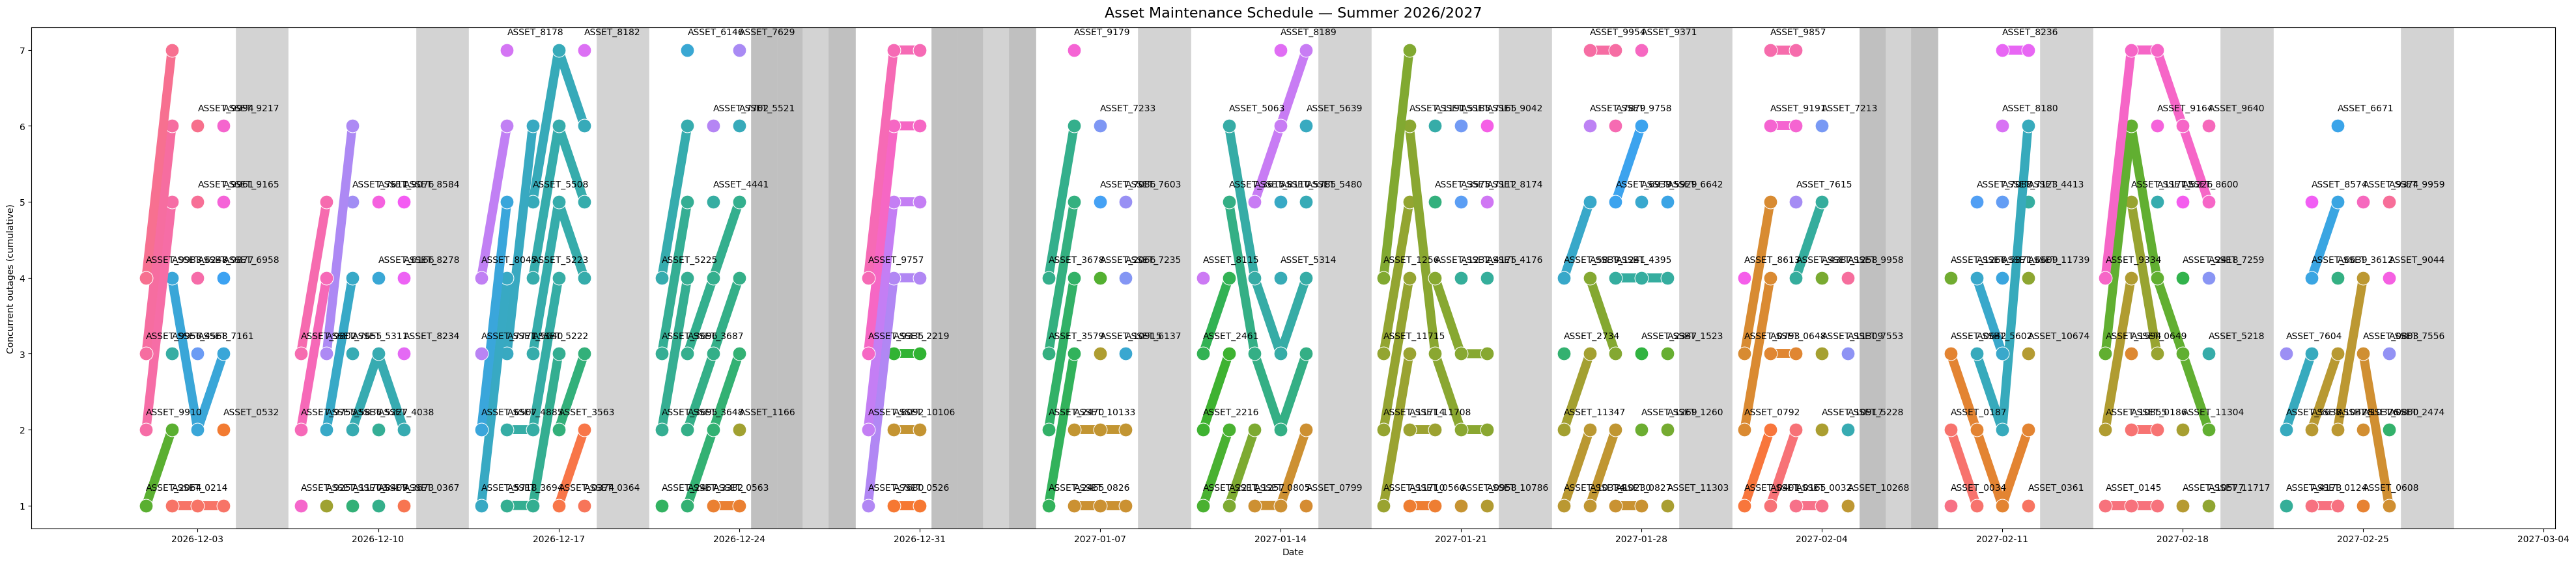

Autumn


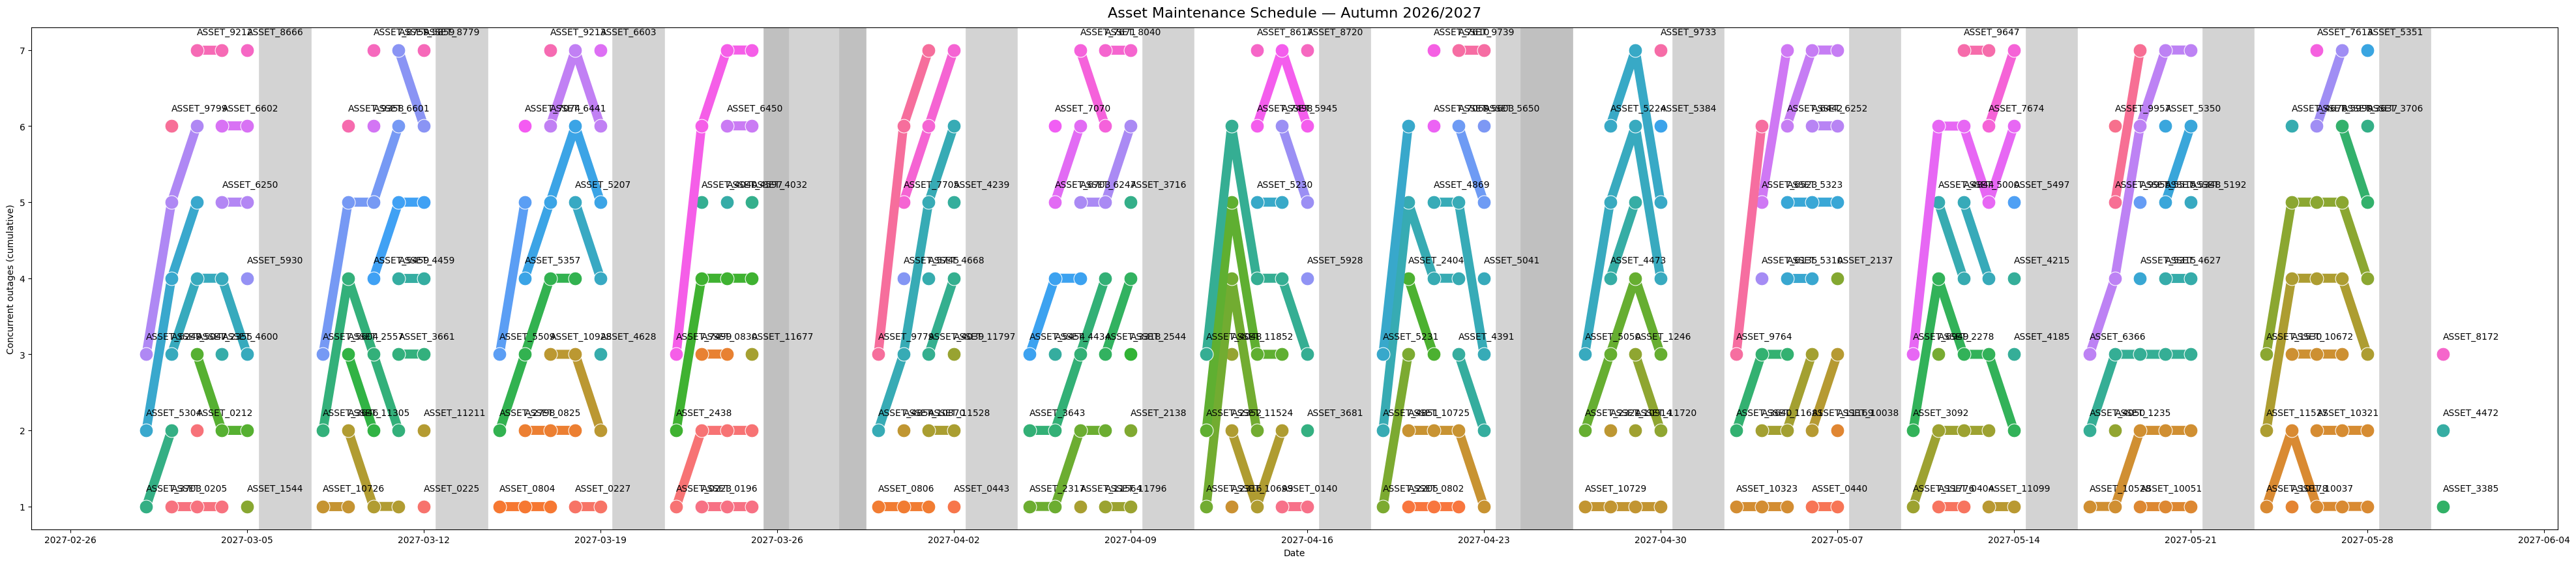

Winter


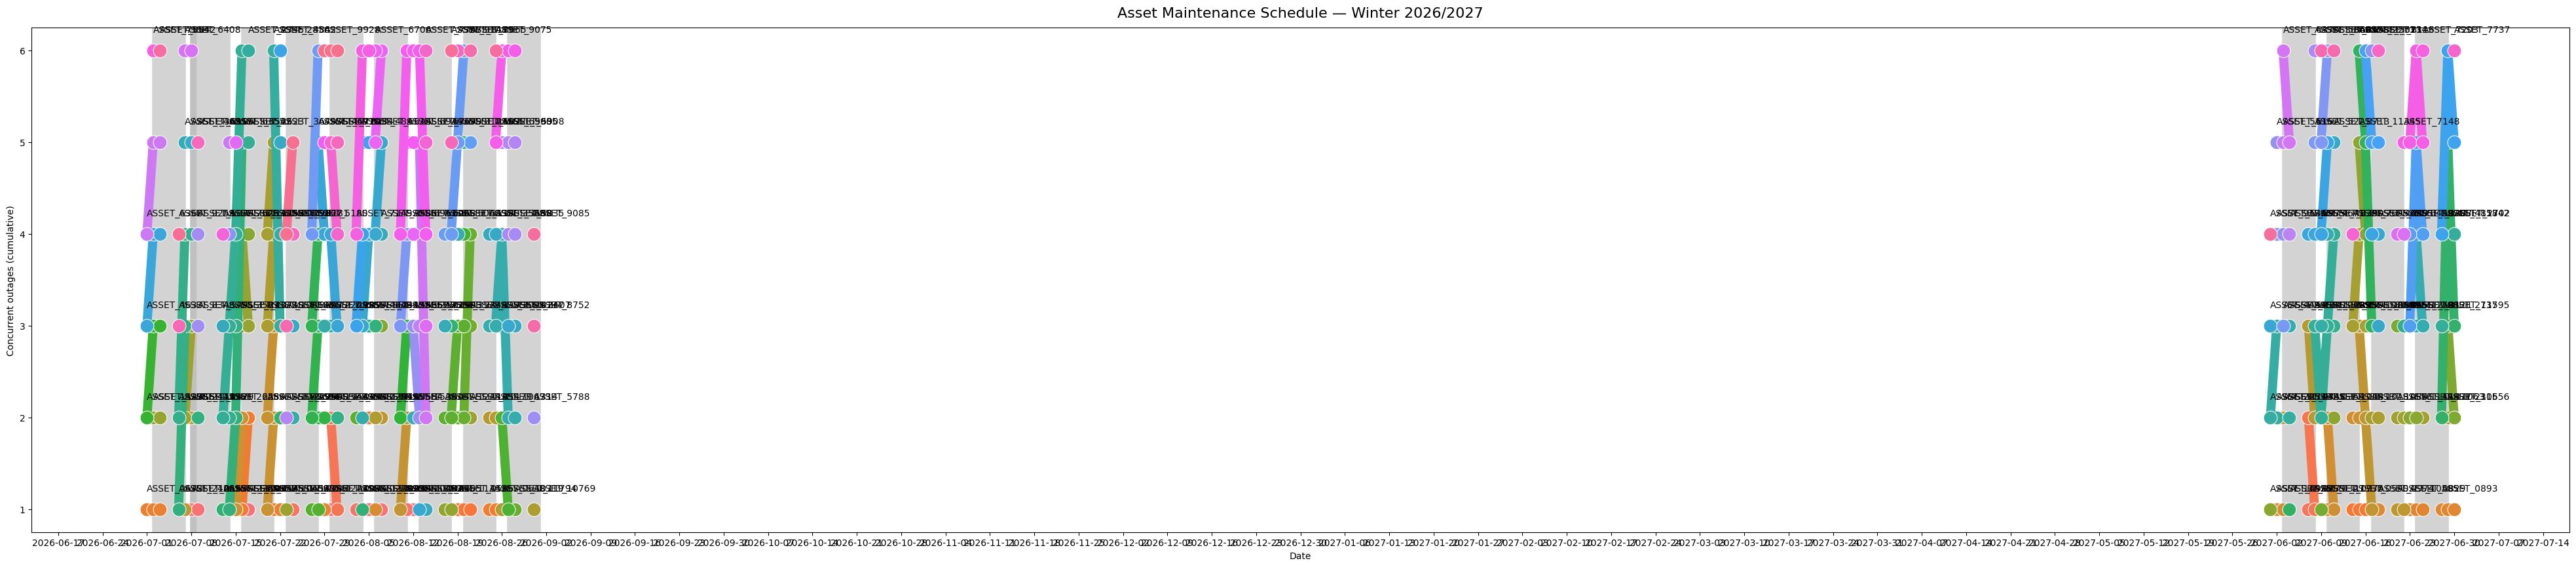

Spring


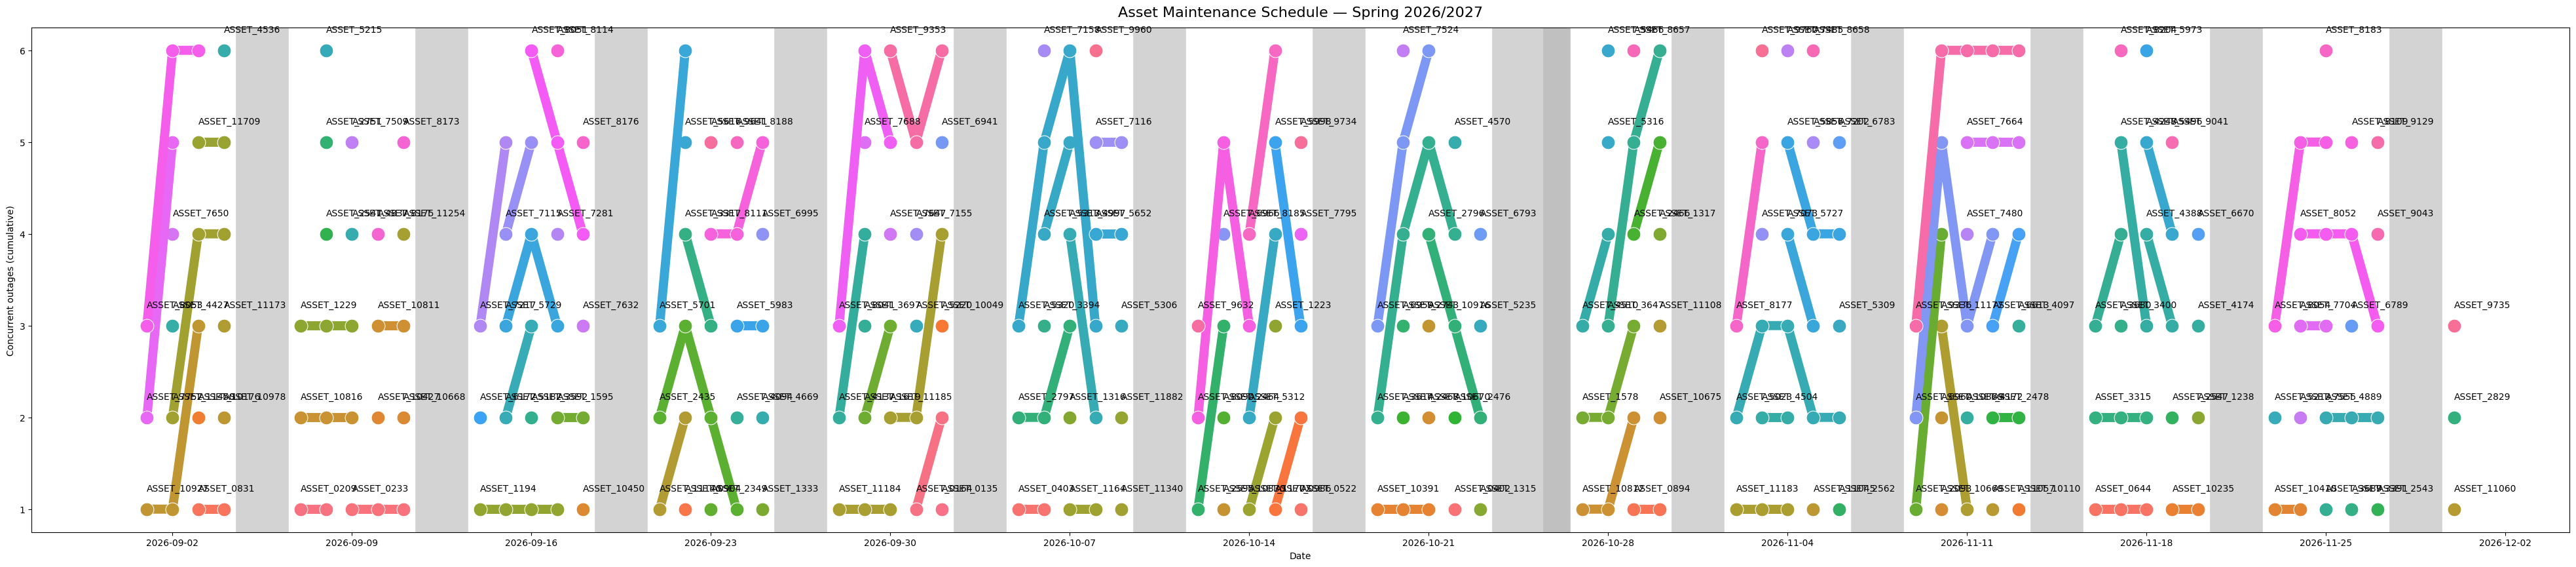


Plots saved:
  notebooks/plots/schedule_Summer_2026.png
  notebooks/plots/schedule_Autumn_2026.png
  notebooks/plots/schedule_Winter_2026.png
  notebooks/plots/schedule_Spring_2026.png


In [10]:
read_and_plot_batch_season_solutions(seasons, config, output_dir="notebooks/plots")

print("\nPlots saved:")
for s in seasons:
    print(f"  notebooks/plots/schedule_{s}_{config['aop_year']}.png")

---
### ⑧ `create_full_season_solutions()` — `scheduler/solution_parser.py`

**Inputs:** reads `07_day_schedule_{season}.xlsx` + `06_mvs_groups_{season}.pkl` per season; `config['asset_requests_filepath']`  
**Output:** writes `08b_season_schedule_{season}.xlsx` per season

Merges the day-level schedule with original asset metadata (planned start/finish dates and times).
Expands each MVS group — adding rows for all dependent assets with dates inherited from
their parent. Derives a `Time Frame` column: `Daily` for single-day assets, `Continuous` for multi-day.

In [11]:
create_full_season_solutions(seasons, config)

print("Output shapes:")
for s in seasons:
    df = pd.read_excel(f"outputs/08b_season_schedule_{s}.xlsx")
    print(f"  08b_season_schedule_{s}.xlsx — {df.shape[0]} rows × {df.shape[1]} cols")

print("\nSample (Summer):")
display(
    pd.read_excel("outputs/08b_season_schedule_Summer.xlsx")
    [["Asset", "Planned Start Date", "Planned Finish Date", "Time Frame"]]
    .head()
)

Output shapes:
  08b_season_schedule_Summer.xlsx — 315 rows × 15 cols
  08b_season_schedule_Autumn.xlsx — 385 rows × 15 cols
  08b_season_schedule_Winter.xlsx — 316 rows × 15 cols
  08b_season_schedule_Spring.xlsx — 349 rows × 15 cols

Sample (Summer):


,Asset,Planned Start Date,Planned Finish Date,Time Frame
0,ASSET_2064,2026-12-01,2026-12-02,Daily
1,ASSET_9910,2026-12-01,2026-12-02,Daily
2,ASSET_9956,2026-12-01,2026-12-02,Daily
3,ASSET_9983,2026-12-01,2026-12-02,Daily
4,ASSET_4574,2026-12-02,2026-12-02,Daily


---
### ⑨ `merge_season_solutions()` — `scheduler/solution_parser.py`

**Input:** reads `08b_season_schedule_{season}.xlsx` for all four seasons  
**Output:** writes `09_draft_aop_{year}_to_{year+1}.xlsx`; returns `df_full_sln`

Concatenates all four seasonal DataFrames, sorts by planned start date, and reformats dates
as `DD/MM/YYYY` strings for OHMS compatibility.

In [12]:
df_full_sln = merge_season_solutions(seasons, config)

aop_year = config["aop_year"]
print(f"Combined AOP: {df_full_sln.shape[0]} rows × {df_full_sln.shape[1]} cols")
print(f"\nDate format sample (DD/MM/YYYY):")
display(
    df_full_sln[["Asset", "Planned Start Date", "Planned Finish Date", "Time Frame"]]
    .head()
)
print(f"\nWritten to: outputs/09_draft_aop_{aop_year}_to_{aop_year + 1}.xlsx")

Combined AOP: 1365 rows × 15 cols

Date format sample (DD/MM/YYYY):


,Asset,Planned Start Date,Planned Finish Date,Time Frame
700,ASSET_0672,01/07/2026,03/07/2026,Continuous
701,ASSET_1527,01/07/2026,03/07/2026,Continuous
702,ASSET_6368,01/07/2026,03/07/2026,Continuous
703,ASSET_4633,01/07/2026,03/07/2026,Continuous
704,ASSET_7554,02/07/2026,02/07/2026,Daily



Written to: outputs/09_draft_aop_2026_to_2027.xlsx


---
### ⑩ `postprocess_data()` — `scheduler/solution_parser.py`

**Input:** reads `09_draft_aop_{year}_to_{year+1}.xlsx`  
**Output:** OHMS-formatted DataFrame; overwrites same file

Transforms column names to UPPERCASE OHMS format and maps abbreviated request reason codes
to full descriptions:

| Code | Maps to |
|------|--------|
| APJ, SEL, CAP | Project |
| PDM, PDM-L, PM, PM Forecast | Station Maintenance |

Adds constant columns `NATURE = "RS"` and `REQUESTOR = ""`.

In [13]:
transformed_df = postprocess_data(config)

print(f"OHMS output shape: {transformed_df.shape}")
print(f"\nColumns: {list(transformed_df.columns)}")
print("\nSample output:")
display(
    transformed_df[
        ["ASSET", "PLANNED START DATE", "PLANNED FINISH DATE", "REQUEST REASONS", "TIME FRAME"]
    ].head(10)
)

OHMS output shape: (1365, 13)

Columns: ['ASSET', 'PLANNED START DATE', 'PLANNED START TIME', 'PLANNED FINISH DATE', 'PLANNED FINISH TIME', 'NATURE', 'TIME FRAME', 'DESCRIPTION OF WORK', 'REQUEST REASONS', 'JOB MANAGER', 'WINDOW OWNERS', 'REQUESTOR', 'MAXIMO SCHEDULING DETAILS']

Sample output:


,ASSET,PLANNED START DATE,PLANNED FINISH DATE,REQUEST REASONS,TIME FRAME
0,ASSET_0672,01/07/2026,03/07/2026,Station Maintenance,Continuous
1,ASSET_1527,01/07/2026,03/07/2026,Station Maintenance,Continuous
2,ASSET_6368,01/07/2026,03/07/2026,"Station Maintenance, Project",Continuous
3,ASSET_4633,01/07/2026,03/07/2026,Station Maintenance,Continuous
4,ASSET_7554,02/07/2026,02/07/2026,Project,Daily
5,ASSET_11315,02/07/2026,03/07/2026,Station Maintenance,Daily
6,ASSET_8842,03/07/2026,03/07/2026,Station Maintenance,Daily
7,ASSET_2477,06/07/2026,08/07/2026,Project,Continuous
8,ASSET_2426,06/07/2026,07/07/2026,Station Maintenance,Daily
9,ASSET_8348,06/07/2026,06/07/2026,Station Maintenance,Daily
